# Classificação de Reclamações Financeiras e Análise das Dores dos Clientes

Este notebook tem como objetivo construir um pipeline de NLP para classificar o sentimento de reclamações financeiras e analisar as principais dores dos clientes por categoria de produto. O projeto atende ao desafio proposto, que exige pré-processamento textual, criação da variável alvo, modelagem com Deep Learning, avaliação por métricas e análise dos principais temas negativos por categoria de produto.

**1. Instalação e imports**

Nesta etapa, foram instaladas e importadas as bibliotecas necessárias para a execução do projeto. Entre elas estão ferramentas para manipulação de dados, processamento de linguagem natural, visualização gráfica, modelagem preditiva e redes neurais. Esse passo é essencial para preparar o ambiente de trabalho e garantir que todas as funções utilizadas ao longo do notebook estejam disponíveis e organizadas desde o início.

In [1]:
!pip install nltk wordcloud scikit-learn tensorflow imbalanced-learn -q

In [2]:
import os
import re
import string
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("vader_lexicon")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

**2. Leitura da base**

Nesta etapa, foi realizado o carregamento do arquivo complaints_processed.csv para um DataFrame do pandas. Embora a documentação do desafio sugira o uso da base original de reclamações do CFPB, foi utilizada a versão disponibilizada no Kaggle conforme sugerido em aula. Além disso, essa base já se apresenta em formato mais enxuto e processado, com colunas diretamente voltadas ao problema, como a categoria do produto e a narrativa da reclamação. Essa escolha tornou o desenvolvimento mais viável no ambiente de notebook, reduziu a complexidade do tratamento inicial de um volume muito grande de dados e permitiu concentrar o esforço nas etapas centrais do desafio, como a criação da variável alvo, a modelagem em Deep Learning e a análise das principais dores dos clientes.

In [3]:
df = pd.read_csv("/content/complaints_processed.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.shape)
print(df.head())
print(df.columns)

(162421, 2)
            product                                          narrative
0       credit_card  purchase order day shipping amount receive pro...
1       credit_card  forwarded message date tue subject please inve...
2    retail_banking  forwarded message cc sent friday pdt subject f...
3  credit_reporting  payment history missing credit report speciali...
4  credit_reporting  payment history missing credit report made mis...
Index(['product', 'narrative'], dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   product    162421 non-null  object
 1   narrative  162411 non-null  object
dtypes: object(2)
memory usage: 2.5+ MB


**3. Limpeza inicial**

Aqui foram removidos registros sem texto válido na coluna narrative. Essa etapa é importante porque o modelo só consegue aprender a partir de conteúdo textual efetivamente preenchido. Também foi feita a remoção de espaços em branco e linhas vazias, garantindo maior qualidade para as próximas fases do pipeline.

In [5]:
df = df.dropna(subset=["narrative"]).copy()
df["narrative"] = df["narrative"].astype(str).str.strip()
df = df[df["narrative"] != ""]

print(df.shape)
print(df["product"].value_counts())

(162411, 2)
product
credit_reporting       91172
debt_collection        23148
mortgages_and_loans    18990
credit_card            15566
retail_banking         13535
Name: count, dtype: int64


**4. Pré-processamento textual**

Este bloco realiza o pré-processamento textual com uma abordagem cuidadosa. Foram criadas duas versões do texto: uma para a rotulagem heurística e outra para a modelagem. A principal preocupação aqui foi preservar palavras de negação, como not, no e never, pois elas alteram fortemente o sentido da reclamação. Essa decisão ajuda a evitar perda de contexto e reduz o risco de distorcer a interpretação do sentimento.

In [6]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

negation_words = {
    "no", "not", "nor", "never", "none", "cannot", "cant", "won't", "wouldn't",
    "didn't", "doesn't", "don't", "isn't", "aren't", "wasn't", "weren't",
    "couldn't", "shouldn't", "hasn't", "haven't", "hadn't"
}

# preserva palavras de negação
stop_words_model = stop_words - negation_words
stop_words_label = stop_words - negation_words

def preprocess_for_label(text):
    text = str(text).lower()
    text = re.sub(r"\bx{2,}\b", " ", text)   # remove mascaramento tipo xxxx
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_for_model(text):
    text = str(text).lower()
    text = re.sub(r"\bx{2,}\b", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words_model and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["text_label"] = df["narrative"].apply(preprocess_for_label)
df["text_model"] = df["narrative"].apply(preprocess_for_model)

df = df[df["text_model"].str.strip() != ""]

print(df[["narrative", "text_label", "text_model"]].head())

                                           narrative  \
0  purchase order day shipping amount receive pro...   
1  forwarded message date tue subject please inve...   
2  forwarded message cc sent friday pdt subject f...   
3  payment history missing credit report speciali...   
4  payment history missing credit report made mis...   

                                          text_label  \
0  purchase order day shipping amount receive pro...   
1  forwarded message date tue subject please inve...   
2  forwarded message cc sent friday pdt subject f...   
3  payment history missing credit report speciali...   
4  payment history missing credit report made mis...   

                                          text_model  
0  purchase order day shipping amount receive pro...  
1  forwarded message date tue subject please inve...  
2  forwarded message sent friday pdt subject fina...  
3  payment history missing credit report speciali...  
4  payment history missing credit report made mis..

**5. Construção da variável alvo (sentimento)**


Neste bloco é construída a variável de sentimento de forma heurística, combinando três sinais principais: presença de palavras-chave negativas, padrões linguísticos recorrentes em reclamações e escore de polaridade do VADER.

Essa estratégia foi adotada porque a base não traz uma variável alvo binária pronta para este problema. Assim, a coluna `sentimento` foi criada para viabilizar o treinamento supervisionado do modelo.

Neste projeto:

- **Negativa** representa reclamações com forte sinal de insatisfação, erro, cobrança indevida, fraude, bloqueio, falha operacional ou problema recorrente;
- **Positiva** representa textos sem sinal negativo forte o suficiente para classificação como negativa.

Importante destacar que, neste contexto, a classe **Positiva** não significa necessariamente elogio. Ela também pode incluir textos neutros, pedidos de informação, acompanhamento de solicitação ou relatos com baixa carga negativa explícita.

In [7]:
sia = SentimentIntensityAnalyzer()

negative_keywords = {
    "fraud", "fraudulent", "unauthorized", "wrong", "error", "complaint",
    "charged", "charge", "debt", "harassment", "denied", "late",
    "dispute", "incorrect", "inaccurate", "problem", "misleading",
    "stolen", "issue", "failed", "failure", "fee", "fees", "interest",
    "delay", "collection", "collector", "threat", "foreclosure",
    "inquiry", "inquiries", "overdraft", "blocked", "billing", "false",
    "victim", "theft", "identity theft", "duplicate charge",
    "scam", "lied", "refused", "damage", "wrongful", "past due",
    "credit report", "credit bureau", "fraud alert", "freeze",
    "hardship", "nightmare", "harming", "harm", "suffering",
    "illegal", "garnishment", "unfair", "late payment",
    "wrong information", "incorrect information", "reduced limit",
    "frozen account", "locked account", "declined", "decline",
    "not available", "delinquent", "frustrating", "frustrated",
    "customer service", "credit score", "collection agency",
    "reporting agency", "police report", "day late",
    "fraudulent account", "opened account", "unknown account",
    "unauthorized inquiry", "credit freeze", "medical account"
}

negative_patterns = {
    "not resolved", "never resolved", "no response", "did not respond",
    "still waiting", "still not", "was not", "were not", "never fixed",
    "not corrected", "wrongly reported", "incorrectly reported",
    "refused to", "failed to", "charged me", "kept calling",
    "without permission", "without consent", "didn't help",
    "would not help", "won't help", "cannot access", "can't access",
    "account locked", "money stolen", "identity stolen"
}

neutral_request_patterns = {
    "please investigate", "please help", "i am requesting",
    "i would like", "for your review", "submitted documents",
    "i sent documents", "i contacted them", "this complaint is regarding"
}

def weak_label(text):
    text = str(text).lower().strip()

    vader_score = sia.polarity_scores(text)["compound"]

    neg_hits = sum(1 for kw in negative_keywords if kw in text)
    neg_pattern_hits = sum(1 for p in negative_patterns if p in text)
    neutral_hits = sum(1 for p in neutral_request_patterns if p in text)

    final_score = (
        vader_score
        - neg_hits * 0.18
        - neg_pattern_hits * 0.45
        - neutral_hits * 0.04
    )

    if neg_pattern_hits >= 1:
        return "Negativa"
    if neg_hits >= 3:
        return "Negativa"
    if final_score <= -0.15:
        return "Negativa"
    return "Positiva"

df["sentimento"] = df["text_label"].apply(weak_label)

print(df["sentimento"].value_counts())

sentimento
Negativa    130716
Positiva     31695
Name: count, dtype: int64


**6. Validação manual da rotulagem**

Este bloco seleciona uma pequena amostra aleatória da base tratada para inspeção qualitativa da rotulagem heurística.

O objetivo não é substituir uma rotulagem humana completa, mas verificar se a regra criada está produzindo classificações coerentes com o conteúdo textual. Essa auditoria amostral aumenta a transparência da metodologia e ajuda a identificar possíveis ruídos na variável alvo.

Como melhoria futura de baixo custo, esta etapa pode ser expandida para uma auditoria manual de 50 a 100 textos, permitindo estimar uma taxa simples de coerência da heurística.

In [8]:
mapa_produtos = {
    "mortgages_and_loans": "hipotecas_e_emprestimos",
    "credit_card": "cartao_de_credito",
    "debt_collection": "cobranca_de_divida",
    "credit_reporting": "relatorio_de_credito",
    "retail_banking": "banco_de_varejo"
}

amostra_validacao = df[["product", "narrative", "text_model", "sentimento"]].sample(20, random_state=42).copy()

amostra_validacao = amostra_validacao.rename(columns={
    "product": "produto",
    "narrative": "narrativa_original",
    "text_model": "texto_tratado",
    "sentimento": "sentimento"
})

amostra_validacao["produto"] = amostra_validacao["produto"].replace(mapa_produtos)
amostra_validacao

,produto,narrativa_original,texto_tratado,sentimento
114592,hipotecas_e_emprestimos,called acima ask bill hold payment told date p...,called acima ask bill hold payment told date p...,Negativa
108967,relatorio_de_credito,sent letter regarding inaccurate unknown thing...,sent letter regarding inaccurate unknown thing...,Negativa
104282,hipotecas_e_emprestimos,purchased new vehicle alabama purchase price n...,purchased new vehicle alabama purchase price n...,Positiva
53752,cobranca_de_divida,contacted many time failed provide necessary d...,contacted many time failed provide necessary d...,Negativa
44725,cartao_de_credito,cancellation trip emailed stating charge done ...,cancellation trip emailed stating charge done ...,Negativa
69927,relatorio_de_credito,received bill immediately called number statem...,received bill immediately called number statem...,Positiva
156958,relatorio_de_credito,one late payment payment car lease reason paym...,one late payment payment car lease reason paym...,Negativa
122102,cartao_de_credito,reliacard money since wont release verified ac...,reliacard money since wont release verified ac...,Positiva
33642,relatorio_de_credito,writing delete following information file item...,writing delete following information file item...,Negativa
57274,cartao_de_credito,never activity account another account consist...,never activity account another account consist...,Positiva


**7. Amostra de positivas (não-negativas)**

Aqui é extraída uma amostra específica da classe Positiva para inspeção qualitativa. O objetivo é confirmar se essa classe realmente contém textos de solicitação, dúvida, acompanhamento ou situações neutras, e não apenas elogios.

In [9]:
positivas_amostra = df[df["sentimento"] == "Positiva"][
    ["product", "narrative", "text_model", "sentimento"]
].sample(min(20, (df["sentimento"] == "Positiva").sum()), random_state=42).copy()

positivas_amostra = positivas_amostra.rename(columns={
    "product": "produto",
    "narrative": "narrativa_original",
    "text_model": "texto_tratado",
    "sentimento": "sentimento"
})

positivas_amostra["produto"] = positivas_amostra["produto"].replace(mapa_produtos)
positivas_amostra

,produto,narrativa_original,texto_tratado,sentimento
75907,relatorio_de_credito,sent letter day ago credit agency havent gotte...,sent letter day ago credit agency havent gotte...,Positiva
68605,relatorio_de_credito,pulled credit first time year derogatory item ...,pulled credit first time year derogatory item ...,Positiva
159560,relatorio_de_credito,tx complaining department mufg union bank dear...,complaining department mufg union bank dear si...,Positiva
132773,cobranca_de_divida,charge reported credit report dewitt hall aske...,charge reported credit report dewitt hall aske...,Positiva
31365,hipotecas_e_emprestimos,process modification submitted document withou...,process modification submitted document withou...,Positiva
135543,relatorio_de_credito,removed item associated bankruptcy except bank...,removed item associated bankruptcy except bank...,Positiva
61926,relatorio_de_credito,app keep track score recently logged saw unkno...,app keep track score recently logged saw unkno...,Positiva
2146,banco_de_varejo,person phone service another phone provider re...,person phone service another phone provider re...,Positiva
155925,relatorio_de_credito,reporting credit limit credit limit reporting ...,reporting credit limit credit limit reporting ...,Positiva
35609,relatorio_de_credito,trying get insurance vehicle time every time g...,trying get insurance vehicle time every time g...,Positiva


**8. Criação da base final para modelagem(Variável Target)**

Neste bloco a variável categórica de sentimento é convertida em variável numérica binária, necessária para o treinamento do modelo. A classe Negativa recebe valor 0 e a classe Positiva recebe valor 1.

In [10]:
df_model = df.copy()

df_model["target"] = df_model["sentimento"].map({
    "Negativa": 0,
    "Positiva": 1
})

print(df_model.shape)
print(df_model["sentimento"].value_counts())

(162411, 6)
sentimento
Negativa    130716
Positiva     31695
Name: count, dtype: int64


In [11]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162411 entries, 0 to 162420
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   product     162411 non-null  object
 1   narrative   162411 non-null  object
 2   text_label  162411 non-null  object
 3   text_model  162411 non-null  object
 4   sentimento  162411 non-null  object
 5   target      162411 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 8.7+ MB


**9. Amostra robusta e representativa para modelagem**

Neste bloco é extraída uma amostra robusta da base, preservando a proporção entre produtos e classes de sentimento.

A adoção de uma amostra foi uma decisão metodológica para reduzir custo computacional e tornar o treinamento viável no ambiente do notebook, sem perder a representatividade geral da distribuição dos dados. Para isso, foi utilizada uma amostragem proporcional por produto e sentimento.

In [12]:
sample_n = 40000

df_sample = (
    df_model
    .groupby(["product", "sentimento"], group_keys=False)
    .apply(lambda x: x.sample(
        n=max(1, round(sample_n * len(x) / len(df_model))),
        random_state=42
    ))
    .reset_index(drop=True)
)

print(df_sample.shape)
print(df_sample.groupby(["product", "sentimento"]).size())

(39999, 6)
product              sentimento
credit_card          Negativa       3091
                     Positiva        743
credit_reporting     Negativa      18395
                     Positiva       4059
debt_collection      Negativa       4896
                     Positiva        805
mortgages_and_loans  Negativa       3495
                     Positiva       1182
retail_banking       Negativa       2316
                     Positiva       1017
dtype: int64


**10. Tokenização dos textos**

Aqui os textos são transformados em sequências numéricas, pois redes neurais não operam diretamente sobre texto bruto. Em seguida, todas as sequências são padronizadas para o mesmo comprimento, permitindo que sejam processadas pela arquitetura BiLSTM.

In [13]:
max_words = 20000
max_len = 120

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df_sample["text_model"])

X_seq = tokenizer.texts_to_sequences(df_sample["text_model"])
X = pad_sequences(X_seq, maxlen=max_len, padding="post", truncating="post")

y = df_sample["target"].values

print(X.shape)
print(y.shape)

(39999, 120)
(39999,)


**11. Separação entre treino e teste**

Neste bloco a base é dividida em conjunto de treino e conjunto de teste. A estratificação garante que a distribuição das classes seja mantida em ambos os subconjuntos, evitando distorções na avaliação do modelo.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

print("Distribuição treino:", np.bincount(y_train))
print("Distribuição teste :", np.bincount(y_test))

(31999, 120) (8000, 120)
(31999,) (8000,)
Distribuição treino: [25754  6245]
Distribuição teste : [6439 1561]


**12. Oversampling apenas no treino**

Esta etapa trata o desbalanceamento entre as classes por meio de oversampling aplicado somente ao conjunto de treino.

Essa escolha é importante porque aumenta a representatividade da classe minoritária durante o aprendizado do modelo, sem alterar artificialmente o conjunto de teste. Dessa forma, a avaliação final permanece mais fiel ao comportamento esperado em dados não balanceados.

In [15]:
ros = RandomOverSampler(random_state=42)

X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print("Antes do oversampling:", np.bincount(y_train))
print("Depois do oversampling:", np.bincount(y_train_res))

Antes do oversampling: [25754  6245]
Depois do oversampling: [25754 25754]


**13. Construção do modelo BiLSTM**

Neste bloco é definida a arquitetura da rede neural BiLSTM. A camada de embedding transforma palavras em vetores densos, enquanto a camada bidirecional LSTM permite capturar dependências contextuais do texto em ambas as direções. As camadas de dropout ajudam a reduzir overfitting, e a camada final com ativação sigmoide realiza a classificação binária.

In [16]:
model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=max_words, output_dim=128),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,662,977 (10.16 MB)

 Trainable params: 2,662,977 (10.16 MB)

 Non-trainable params: 0 (0.00 B)

**14. Treinamento do modelo**

Aqui o modelo é treinado utilizando o conjunto balanceado de treino. Também é aplicado o mecanismo de early stopping, que interrompe o treinamento caso o desempenho de validação deixe de melhorar, evitando sobreajuste.

In [17]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_res,
    y_train_res,
    validation_split=0.2,
    epochs=8,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 131s 394ms/step - accuracy: 0.8478 - loss: 0.3506 - val_accuracy: 0.8996 - val_loss: 0.2727
Epoch 2/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 126s 391ms/step - accuracy: 0.9230 - loss: 0.2016 - val_accuracy: 0.9378 - val_loss: 0.1878
Epoch 3/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 126s 392ms/step - accuracy: 0.9468 - loss: 0.1459 - val_accuracy: 0.9288 - val_loss: 0.1934
Epoch 4/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 124s 386ms/step - accuracy: 0.9623 - loss: 0.1042 - val_accuracy: 0.9531 - val_loss: 0.1361
Epoch 5/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 125s 390ms/step - accuracy: 0.9677 - loss: 0.0917 - val_accuracy: 0.9676 - val_loss: 0.1019
Epoch 6/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 126s 392ms/step - accuracy: 0.9766 - loss: 0.0667 - val_accuracy: 0.9849 - val_loss: 0.0457
Epoch 7/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 126s 391ms/step - accuracy: 0.9827 - loss: 0.0530 - val_accuracy: 0.9751 - val_loss: 0.0818
Epoch 8/8
322/322 ━━━━━━━━━━━━━━━━━━━━ 143s 395ms/step - accuracy: 0.9837 - loss: 0

**15. Busca do melhor threshold**

Neste bloco são testados diferentes limiares de decisão para converter a probabilidade prevista em classe final.

Em vez de adotar automaticamente o valor de 0,5, foram avaliados múltiplos thresholds para identificar o ponto que melhor equilibra precisão e recall, usando o F1-score como critério principal. Essa etapa é especialmente relevante em cenários com desbalanceamento entre classes.

In [18]:
y_prob = model.predict(X_test).ravel()

thresholds = np.arange(0.30, 0.81, 0.05)
resultados_threshold = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    resultados_threshold.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0)
    })

df_thresholds = pd.DataFrame(resultados_threshold)
df_thresholds

250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step


,threshold,accuracy,precision,recall,f1
0,0.30,0.895875,0.704494,0.803331,0.750673
1,0.35,0.897500,0.712565,0.795644,0.751816
2,0.40,0.898250,0.718293,0.787316,0.751222
3,0.45,0.901500,0.729923,0.786035,0.756940
4,0.50,0.902250,0.734780,0.780910,0.757143
5,0.55,0.901750,0.736425,0.773222,0.754375
6,0.60,0.902375,0.742839,0.764254,0.753394
7,0.65,0.903000,0.748261,0.757848,0.753024
8,0.70,0.904125,0.756129,0.750801,0.753455
9,0.75,0.906500,0.768672,0.745035,0.756669


**16.Escolha do threshold final**

O threshold final selecionado representa o ponto de melhor equilíbrio entre recuperação da classe positiva e precisão da classificação. Quando o melhor valor encontrado fica abaixo de 0,5, isso indica que um corte mais permissivo ajuda a identificar melhor os casos positivos sem comprometer excessivamente o desempenho global.

In [19]:
best_row = df_thresholds.sort_values(by="f1", ascending=False).iloc[0]
best_threshold = best_row["threshold"]

print("Melhor threshold pelo F1:", best_threshold)
print(best_row)

Melhor threshold pelo F1: 0.7999999999999998
threshold    0.800000
accuracy     0.908000
precision    0.778905
recall       0.737988
f1           0.757895
Name: 10, dtype: float64


**17.Avaliação final**

Nesta etapa são calculadas as métricas finais do modelo, incluindo acurácia, precisão, recall e F1-score. Também é exibido o relatório de classificação por classe, permitindo avaliar separadamente o desempenho para casos Negativos e Positivos.

In [20]:
y_pred = (y_prob >= best_threshold).astype(int)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-score :", round(f1_score(y_test, y_pred), 4))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=["Negativa", "Positiva"]))

Accuracy : 0.908
Precision: 0.7789
Recall   : 0.738
F1-score : 0.7579

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativa       0.94      0.95      0.94      6439
    Positiva       0.78      0.74      0.76      1561

    accuracy                           0.91      8000
   macro avg       0.86      0.84      0.85      8000
weighted avg       0.91      0.91      0.91      8000



**18. Matriz de confusão**

A matriz de confusão mostra, de forma detalhada, quantas observações foram corretamente ou incorretamente classificadas. Com ela, é possível visualizar falsos positivos, falsos negativos, acertos da classe negativa e acertos da classe positiva.

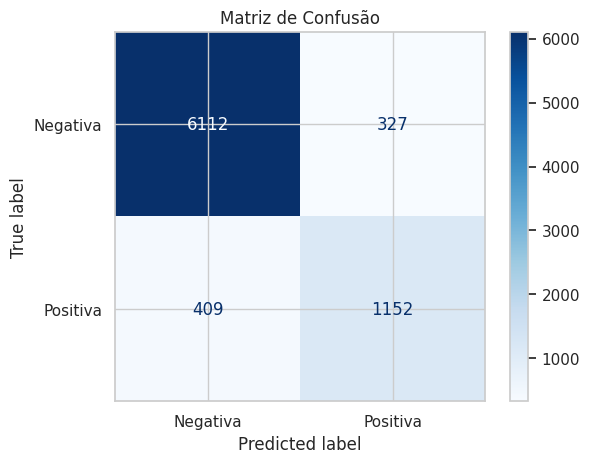

In [21]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativa", "Positiva"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão")
plt.show()

**19. Curvas de treino**

Este bloco apresenta a evolução da perda e da acurácia ao longo das épocas de treinamento. Esses gráficos ajudam a verificar se o modelo convergiu de forma estável e se houve sinais de sobreajuste.

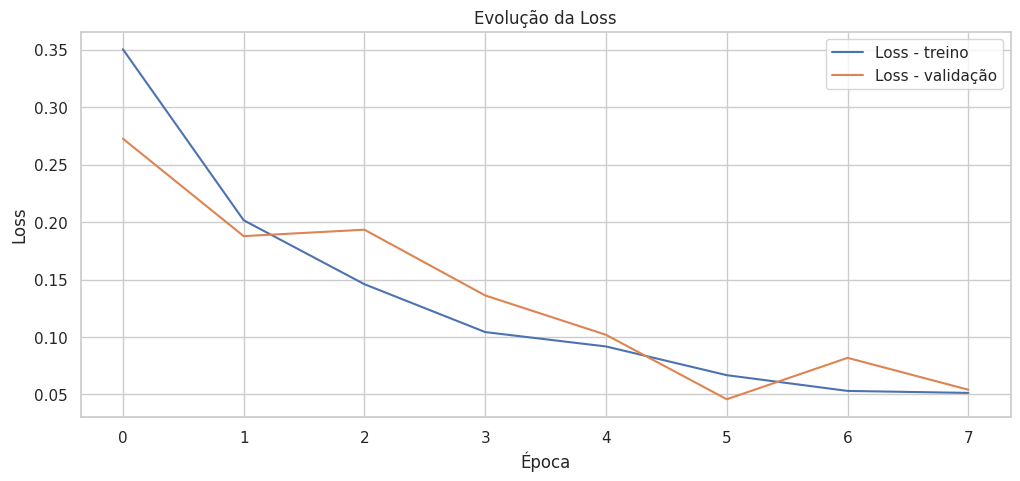

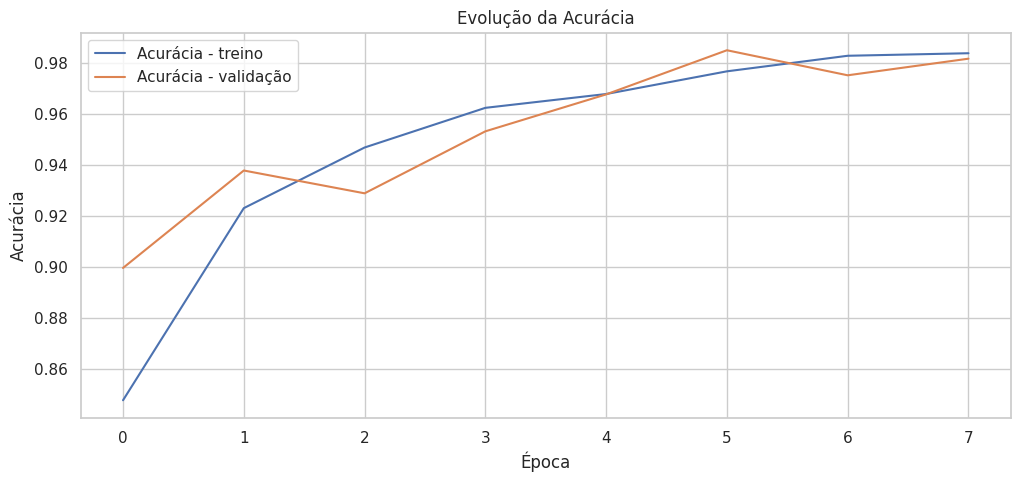

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(history.history["loss"], label="Loss - treino")
plt.plot(history.history["val_loss"], label="Loss - validação")
plt.title("Evolução da Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(history.history["accuracy"], label="Acurácia - treino")
plt.plot(history.history["val_accuracy"], label="Acurácia - validação")
plt.title("Evolução da Acurácia")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.show()

**20. Filtrar reclamações negativas para análise das dores**

---



Como o desafio pede a análise das principais dores relatadas pelos clientes, foi criada uma base específica contendo apenas os registros classificados como negativos. Essa filtragem permite concentrar a exploração textual nos casos em que há evidência mais forte de insatisfação, problema persistente ou falha no atendimento.

In [23]:
df_neg = df_model[df_model["sentimento"] == "Negativa"].copy()

print(df_neg.shape)
print(df_neg["product"].value_counts())

(130716, 6)
product
credit_reporting       74690
debt_collection        19881
mortgages_and_loans    14191
credit_card            12549
retail_banking          9405
Name: count, dtype: int64


**21. Produtos com maior volume de reclamações negativas**

Nesta etapa foi analisada a distribuição das reclamações negativas por categoria de produto. O objetivo é identificar quais segmentos concentram maior volume de insatisfação, fornecendo uma primeira visão de quais serviços financeiros geram mais dor para os clientes.

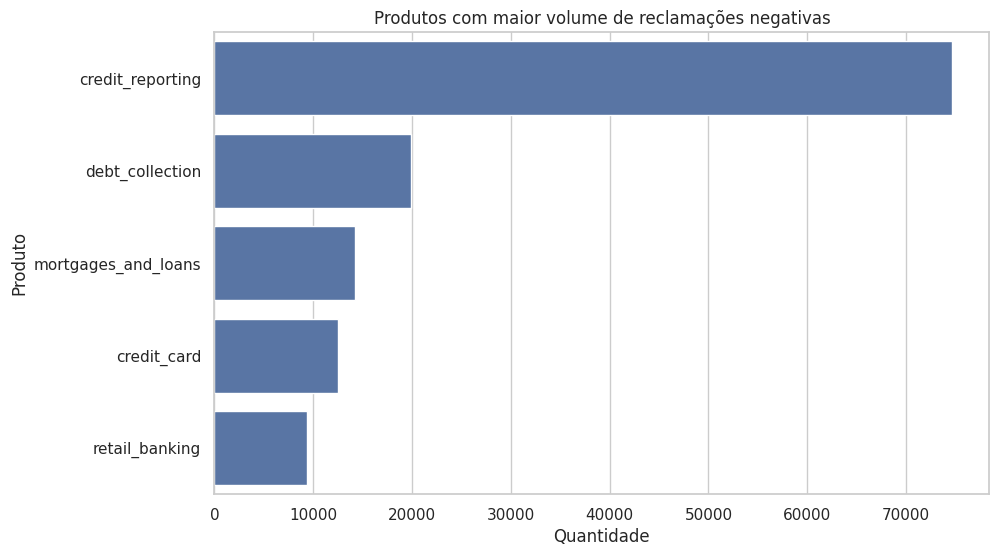

In [24]:
top_produtos = df_neg["product"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_produtos.values, y=top_produtos.index)
plt.title("Produtos com maior volume de reclamações negativas")
plt.xlabel("Quantidade")
plt.ylabel("Produto")
plt.show()

**22. Termos mais relevantes por categoria com TF-IDF**

Foi utilizada a técnica de TF-IDF para identificar os termos mais relevantes nas reclamações negativas de cada categoria de produto. Diferentemente de uma contagem simples de frequência, o TF-IDF destaca palavras e expressões mais características de cada grupo, tornando a análise temática mais precisa.

In [25]:
def top_terms_by_product(data, product_name, top_n=15):
    subset = data[data["product"] == product_name]

    if subset.empty:
        return pd.DataFrame(columns=["term", "score"])

    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        max_features=3000
    )

    X_prod = vectorizer.fit_transform(subset["text_model"])
    scores = np.asarray(X_prod.mean(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())

    top_idx = scores.argsort()[::-1][:top_n]

    return pd.DataFrame({
        "term": terms[top_idx],
        "score": scores[top_idx]
    })

**23. Exibir termos por categoria**

Aqui os termos mais relevantes foram exibidos separadamente por categoria de produto. Essa análise permite comparar os principais assuntos das reclamações negativas entre segmentos como cartão de crédito, relatório de crédito, hipotecas, cobrança de dívida e banco de varejo.

In [26]:
for prod in df_neg["product"].value_counts().index:
    print(f"\nProduto: {prod}")
    display(top_terms_by_product(df_neg, prod, top_n=10))


Produto: credit_reporting


,term,score
0,account,0.074419
1,credit,0.074253
2,report,0.056525
3,credit report,0.040234
4,information,0.040063
5,reporting,0.035170
6,payment,0.030248
7,dispute,0.028339
8,day,0.027234
9,bureau,0.026958



Produto: debt_collection


,term,score
0,debt,0.068630
1,credit,0.057558
2,account,0.056626
3,collection,0.041538
4,report,0.039582
5,company,0.038293
6,credit report,0.029660
7,information,0.029283
8,letter,0.028366
9,received,0.026209



Produto: mortgages_and_loans


,term,score
0,payment,0.069580
1,loan,0.059082
2,mortgage,0.044021
3,account,0.036644
4,credit,0.034068
5,company,0.030175
6,time,0.029712
7,told,0.027950
8,month,0.027460
9,bank,0.026726



Produto: credit_card


,term,score
0,card,0.062774
1,credit,0.058401
2,account,0.054630
3,payment,0.047850
4,charge,0.038255
5,bank,0.036000
6,credit card,0.030116
7,time,0.028353
8,late,0.027650
9,fee,0.025800



Produto: retail_banking


,term,score
0,account,0.084186
1,bank,0.059228
2,money,0.043270
3,check,0.032822
4,paypal,0.031366
5,fund,0.029321
6,transaction,0.029303
7,card,0.029148
8,told,0.028088
9,day,0.027447


**24. Gráfico dos termos mais relevantes de um produto**

Este gráfico resume visualmente os termos mais relevantes de uma categoria específica, facilitando a leitura dos principais temas associados às reclamações negativas daquele produto. A visualização ajuda a transformar a saída técnica em insight interpretável.

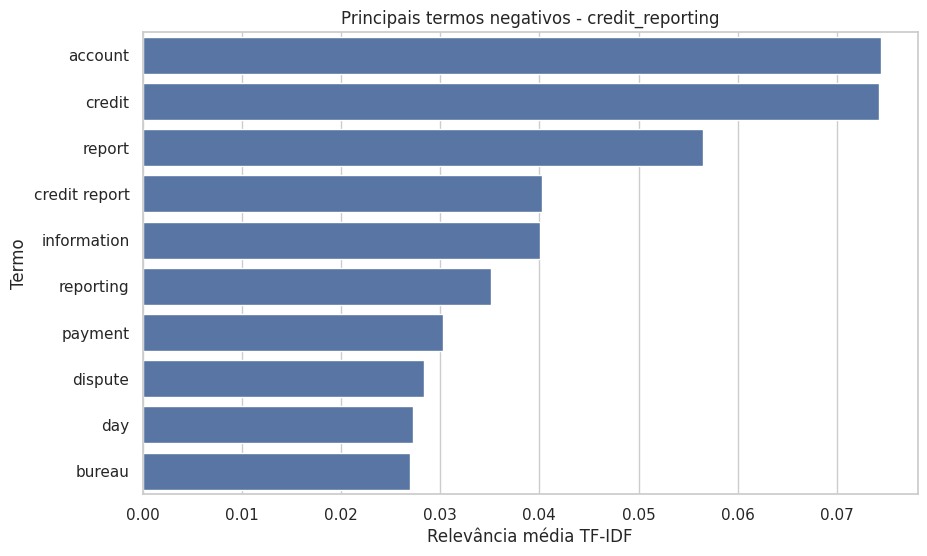

In [27]:
produto_escolhido = df_neg["product"].value_counts().index[0]
top_df = top_terms_by_product(df_neg, produto_escolhido, top_n=10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_df, x="score", y="term")
plt.title(f"Principais termos negativos - {produto_escolhido}")
plt.xlabel("Relevância média TF-IDF")
plt.ylabel("Termo")
plt.show()

**25. Bigramas por categoria**

Nesta etapa, os bigramas mais frequentes foram apresentados por categoria de produto. Essa análise complementa o TF-IDF ao destacar expressões compostas que resumem melhor os problemas enfrentados pelos clientes. Assim, torna-se mais fácil identificar padrões de insatisfação recorrentes dentro de cada segmento financeiro.

In [28]:
def extract_bigrams(data, product_name, top_n=10):
    subset = data[data["product"] == product_name]

    if subset.empty:
        return pd.DataFrame(columns=["bigram", "freq"])

    vec = CountVectorizer(
        stop_words="english",
        ngram_range=(2, 2),
        max_features=1000
    )

    X_bg = vec.fit_transform(subset["text_model"])
    freqs = np.asarray(X_bg.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())

    top_idx = freqs.argsort()[::-1][:top_n]

    return pd.DataFrame({
        "bigram": terms[top_idx],
        "freq": freqs[top_idx]
    })

**26. Exibir bigramas por produto**

Nesta etapa, os bigramas mais frequentes foram apresentados por categoria de produto. Isso complementa a análise por TF-IDF ao destacar expressões compostas que resumem melhor os problemas vivenciados pelos clientes em cada segmento.

In [29]:
for prod in df_neg["product"].value_counts().index:
    print(f"\n==== {prod} ====")
    display(extract_bigrams(df_neg, prod, top_n=10))


==== credit_reporting ====


,bigram,freq
0,credit report,72624
1,identity theft,23657
2,credit bureau,22624
3,credit reporting,21171
4,reporting agency,17279
5,fair credit,11885
6,account number,10841
7,information credit,10677
8,inaccurate information,10124
9,late payment,9895



==== debt_collection ====


,bigram,freq
0,credit report,12027
1,collection agency,4559
2,credit bureau,4488
3,identity theft,3754
4,debt collection,3649
5,credit reporting,3600
6,original creditor,2939
7,debt collector,2808
8,alleged debt,2648
9,credit card,2497



==== mortgages_and_loans ====


,bigram,freq
0,customer service,2777
1,mortgage payment,2571
2,credit report,2549
3,make payment,2395
4,mortgage company,2175
5,late fee,2081
6,late payment,2044
7,monthly payment,1885
8,credit score,1691
9,escrow account,1647



==== credit_card ====


,bigram,freq
0,credit card,11514
1,customer service,3399
2,late fee,2336
3,credit report,2261
4,bank america,2105
5,late payment,1707
6,credit score,1690
7,american express,1676
8,card company,1488
9,credit limit,1431



==== retail_banking ====


,bigram,freq
0,checking account,3205
1,bank america,2686
2,customer service,2199
3,bank account,2116
4,debit card,2078
5,saving account,1309
6,account closed,1228
7,credit card,1194
8,chase bank,1147
9,cash app,1132


**27. Nuvem de palavras por categoria**

As nuvens de palavras oferecem uma visualização rápida dos termos mais frequentes nas reclamações negativas por categoria. Embora sejam mais exploratórias do que o TF-IDF, elas ajudam a comunicar visualmente os temas predominantes ao leitor e atendem ao requisito de geração de visualizações do desafio.

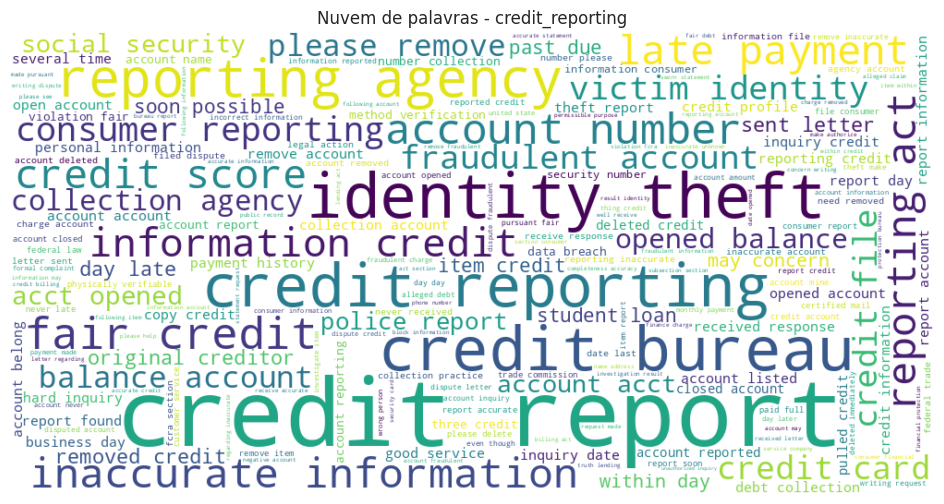

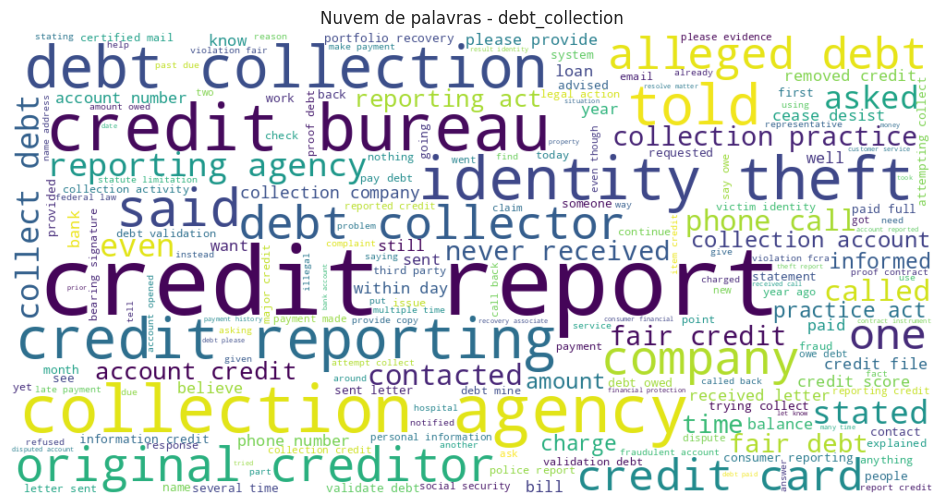

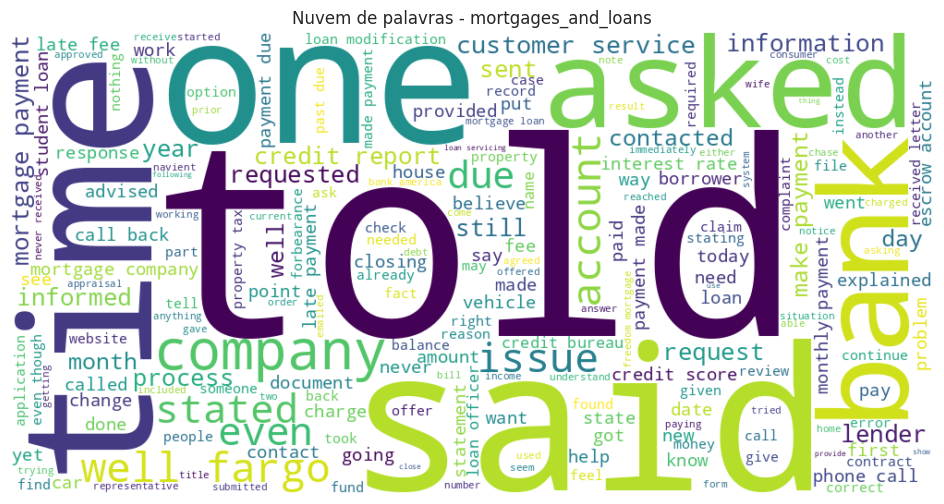

In [30]:
for produto in df_neg["product"].value_counts().index[:3]:
    texto = " ".join(df_neg[df_neg["product"] == produto]["text_model"])

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate(texto)

    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Nuvem de palavras - {produto}")
    plt.show()

**Síntese dos principais temas de insatisfação**

Com base nos termos mais relevantes, nos bigramas e nas visualizações geradas, observam-se alguns padrões recorrentes nas reclamações negativas por categoria:

- **credit_reporting**: informações incorretas no relatório, dificuldade de correção e impacto no histórico de crédito;
- **debt_collection**: cobrança indevida, dívidas não reconhecidas e abordagem excessiva de cobrança;
- **mortgages_and_loans**: problemas com pagamento, taxas, atraso no processamento e servicing;
- **credit_card**: cobranças, tarifas, disputas de transação, limite e falhas operacionais;
- **retail_banking**: bloqueios de conta, dificuldades de acesso, fraude e problemas em transferências.


**28. Salvar modelo e tokenizer**

Nesta etapa, foram salvos o modelo treinado e o tokenizer utilizado na preparação dos textos. Isso permite reutilizar a solução sem repetir todo o processo de treinamento e organização do pipeline, além de tornar a entrega mais profissional e reprodutível.



In [31]:
os.makedirs("outputs/modelo", exist_ok=True)

model.save("outputs/modelo/modelo_bilstm_sentimento.h5")

with open("outputs/modelo/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Modelo e tokenizer salvos com sucesso.")

Modelo e tokenizer salvos com sucesso.


**29. Resumos finais para a conclusão**

Por fim, foram consolidados resumos da distribuição final dos sentimentos e das categorias de produto com maior volume de reclamações negativas. Esses resultados servem de base para a conclusão do notebook, conectando os achados técnicos da modelagem aos principais insights de negócio do desafio.

In [32]:
print("Distribuição final de sentimentos:")
print(df_model["sentimento"].value_counts())

print("\nTop 5 produtos com mais reclamações negativas:")
print(df_neg["product"].value_counts().head(5))

print("\nThreshold final utilizado:", best_threshold)

Distribuição final de sentimentos:
sentimento
Negativa    130716
Positiva     31695
Name: count, dtype: int64

Top 5 produtos com mais reclamações negativas:
product
credit_reporting       74690
debt_collection        19881
mortgages_and_loans    14191
credit_card            12549
retail_banking          9405
Name: count, dtype: int64

Threshold final utilizado: 0.7999999999999998
